# setting up

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('poster')

import scanpy as sc 

In [2]:
from SingleCellArchetype.main import SCA
from SingleCellArchetype.utils import plot_archetype

# Load data

In [3]:
%%time
f_anndata_in   = "../../data/v1_multiome/Saumya_2026/filtered_feature_bc_matrix_recount_multiome_p21a.h5"
f_anndata_out  = "../../data/v1_multiome/Saumya_2026/recount_multiome_p21a_hvg.h5ad"
adata = sc.read_10x_h5(f_anndata_in)
# adata = adata[adata.obs['Age']=='P21']
adata

CPU times: user 1.59 s, sys: 610 ms, total: 2.2 s
Wall time: 2.35 s


AnnData object with n_obs × n_vars = 7811 × 54129
    var: 'gene_ids', 'feature_types', 'genome'

# Prep data - select HVGs

In [4]:
# remove mitocondria genes
adata = adata[:,~adata.var.index.str.contains(r'^mt-')]
adata = adata[:,~adata.var.index.str.contains(r'Xist')]

In [5]:
# filter genes
cond = np.ravel((adata.X>0).sum(axis=0)) > 10 # expressed in more than 10 cells
adata = adata[:,cond]
genes = adata.var.index.values

# counts
x = adata.X
cov = np.array(adata.X.sum(axis=1)).reshape(-1,) # .shape

# CP10k
# xn = x/cov.reshape(x.shape[0], -1)*1e4
xn = (sparse.diags(1/cov).dot(x))*1e4

# log2(CP10k+1)
# xln = xn.copy()
# xln.data = np.log2(xln.data+1)

In [6]:
# adata.layers[    'norm'] = np.array(xn.todense())

log_xn = np.log2(1+np.array(xn.todense()))
adata.layers[ 'lognorm'] = log_xn 
adata.layers['zlognorm'] = zscore(log_xn, axis=0)

In [7]:
# select HVGs with mean and var
nbin = 20
qth = 0.3

# min
gm = np.ravel(xn.mean(axis=0))

# var
tmp = xn.copy()
tmp.data = np.power(tmp.data, 2)
gv = np.ravel(tmp.mean(axis=0))-gm**2

# cut 
lbl = pd.qcut(gm, nbin, labels=np.arange(nbin))
gres = pd.DataFrame()
gres['name'] = genes
gres['lbl'] = lbl
gres['mean'] = gm
gres['var'] = gv
gres['ratio']= gv/gm

# select
gres_sel = gres.groupby('lbl')['ratio'].nlargest(int(qth*(len(gm)/nbin))) #.reset_index()
gsel_idx = np.sort(gres_sel.index.get_level_values(1).values)
assert np.all(gsel_idx != -1)

In [8]:
adata_hvg = adata[:,gsel_idx].copy()
print(adata_hvg.shape)
genes_hvg = adata_hvg.var.index.values

(7811, 8680)


# UMAP - markers - get IT population

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from umap import UMAP

np.random.seed(0)

mat = adata_hvg.layers['lognorm']
# scaled_data = StandardScaler().fit_transform(mat)
pcs = PCA(n_components=30).fit_transform(mat)
ucs = UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=0).fit_transform(pcs)

adata_hvg.obsm['my_pcs'] = pcs
adata_hvg.obsm['my_ucs'] = pcs

sc.pp.neighbors(adata_hvg, n_neighbors=30, use_rep='my_pcs')
sc.tl.leiden(adata_hvg, resolution=1, key_added='cluster')

<Axes: xlabel='u1', ylabel='u2'>

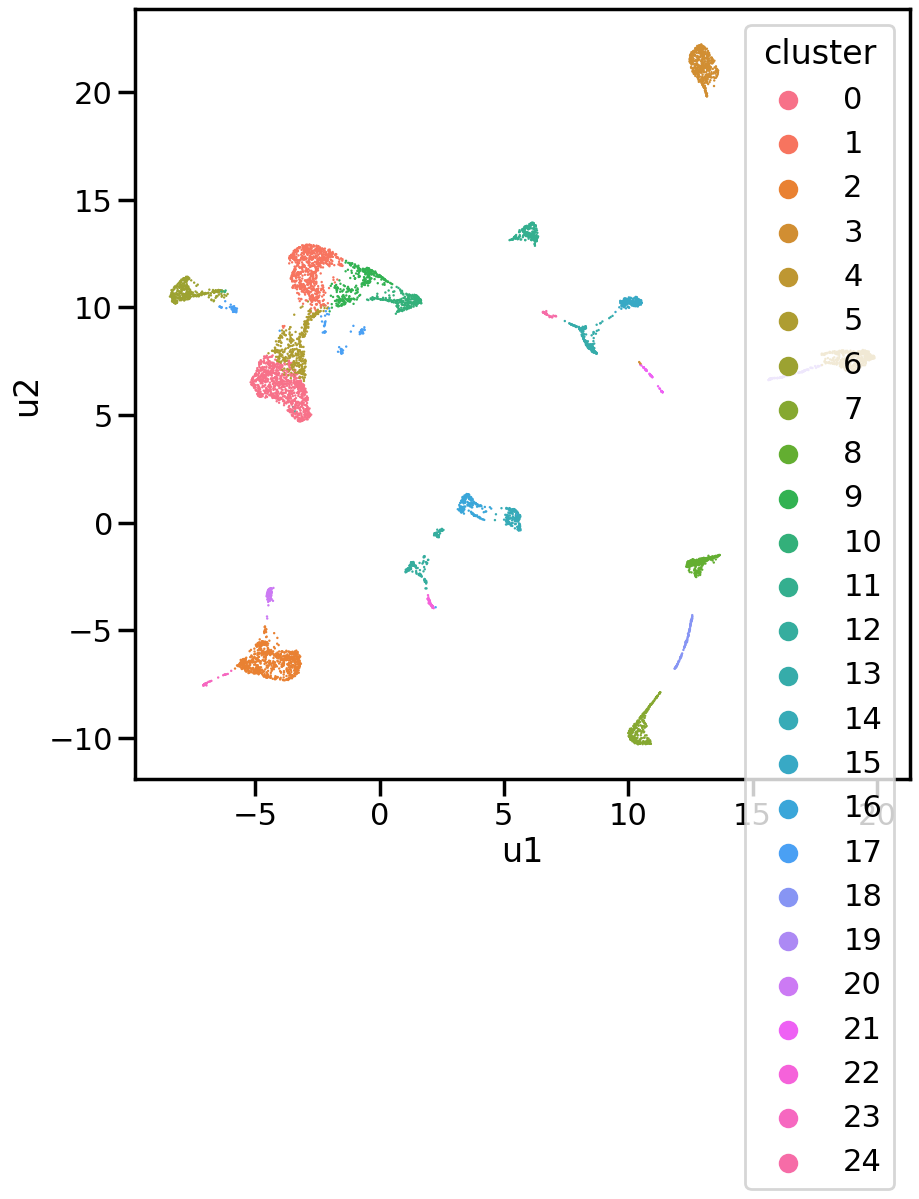

In [10]:
df = adata_hvg.obs.copy()
df['u1'] = ucs[:,0]
df['u2'] = ucs[:,1]

fig, ax = plt.subplots(1,1, figsize=(10, 10))
sns.scatterplot(data=df, x='u1', y='u2', hue='cluster', s=3, edgecolor='none')



# Label transfer from Old data

In [11]:
f_anndata_in_old = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/superdupermegaRNA_hasraw_multiome_P21NRDR.h5ad"
adata_old = sc.read(f_anndata_in_old)
adata_old

AnnData object with n_obs × n_vars = 31039 × 16572
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'

In [12]:
adata_old.obs['Subclass']

AAACCGAAGTTCCTGC-1-P21a-2023 Multiome-9-0        L2/3
AAACGCGCAATCATGT-1-P21a-2023 Multiome-9-0        L2/3
AAACGCGCAGTTGCGT-1-P21a-2023 Multiome-9-0        L2/3
AAACGCGCATTGTGTG-1-P21a-2023 Multiome-9-0        L2/3
AAAGCAAGTTGACTTC-1-P21a-2023 Multiome-9-0        L2/3
                                                ...  
GAGGGAGCATAATGAG-1-P21DRb-2023 Multiome-10-0    Astro
TGAGTTTCAATATAGG-1-P21DRa-2023 Multiome-10-0    Micro
GAGAAACGTTAGCATG-1-P21DRa-2023 Multiome-10-0    Astro
CCTCAAACAGTTAAAG-1-P21DRb-2023 Multiome-10-0       OD
GTTACGCCATAGACCC-1-P21DRb-2023 Multiome-10-0      OPC
Name: Subclass, Length: 31039, dtype: category
Categories (21, object): ['Astro', 'Endo', 'Frem1', 'L2/3', ..., 'Sst', 'Stac', 'VLMC', 'Vip']

## Do the transfer

/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


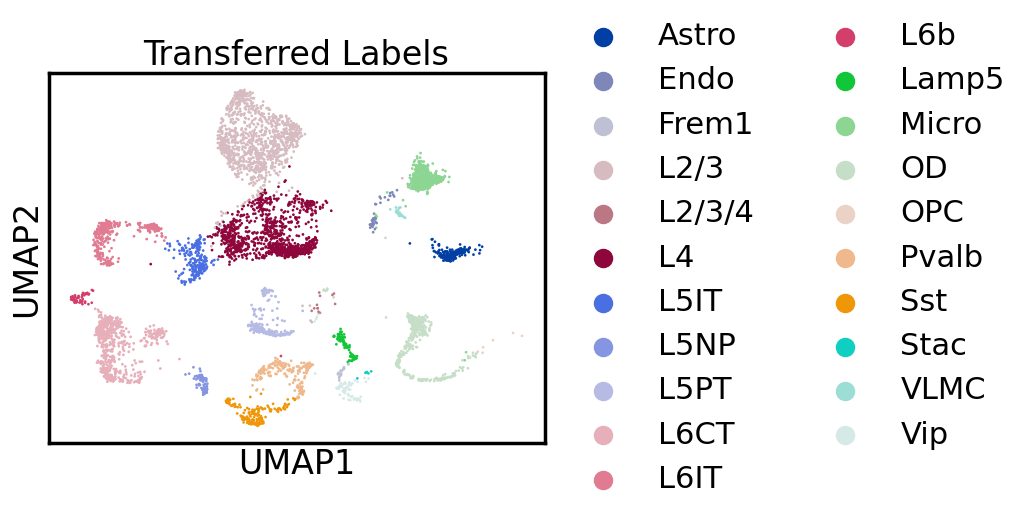

In [13]:
import scanpy as sc

# 1. Load your datasets
# adata_ref: fully annotated reference
# adata_query: unannotated data to be labeled
adata_ref = adata_old
adata_query = adata_hvg

# 2. Subset to common genes (required for mapping)
common_genes = adata_ref.var_names.intersection(adata_query.var_names)
adata_ref = adata_ref[:, common_genes].copy()
adata_query = adata_query[:, common_genes].copy()

# 3. Ensure the reference is prepared
# Ingest requires a fitted PCA and neighbors graph on the reference
sc.pp.pca(adata_ref)
sc.pp.neighbors(adata_ref)
sc.tl.umap(adata_ref)

# 4. Perform Label Transfer
# 'cell_type' is the column in adata_ref.obs containing the labels
sc.tl.ingest(adata_query, adata_ref, obs='Subclass')

# 5. Visualize Results
# Ingest maps the query into the reference UMAP space as 'X_umap'
sc.pl.umap(adata_query, color='Subclass', title='Transferred Labels')


## Visualize transfered labels on query data UMAP 

In [14]:
df = adata_query.obs.copy()
df['u1'] = ucs[:,0]
df['u2'] = ucs[:,1]
df['isIT'] = df['Subclass'].isin(['L2/3', 'L4', 'L5IT', 'L6IT'])
df

,cluster,Subclass,u1,u2,isIT
AAACAGCCAACCTGGT-1,2,L6CT,-5.496867,-6.344100,False
AAACAGCCAAGGTGGC-1,0,L2/3,-2.973351,5.266031,True
AAACAGCCACCAAAGG-1,1,L4,-2.289354,12.329081,True
AAACAGCCACTTCATC-1,4,Astro,19.632393,7.769234,False
AAACAGCCAGTAGGTG-1,1,L4,-2.934685,12.279346,True
...,...,...,...,...,...
TTTGTGTTCCTAACGG-1,14,Pvalb,5.581197,-0.310889,False
TTTGTGTTCGTCATTT-1,4,Astro,19.293621,7.956291,False
TTTGTGTTCTGGCATG-1,2,L6CT,-4.884171,-6.956376,False
TTTGTGTTCTTAGGAC-1,13,Micro,8.279362,9.106954,False


<Axes: xlabel='u1', ylabel='u2'>

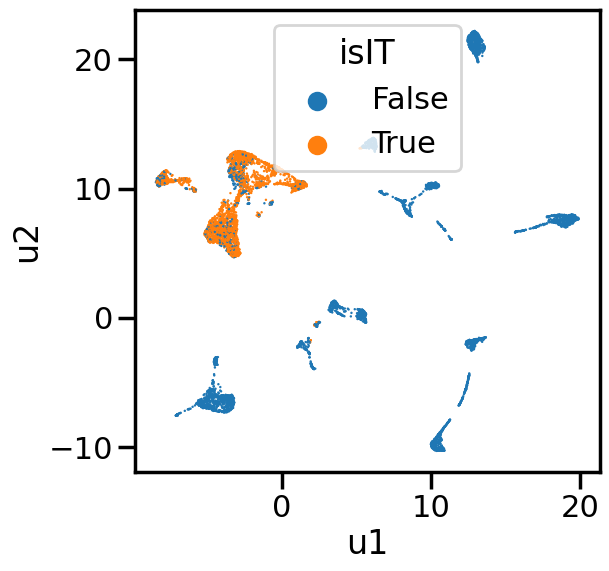

In [15]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
sns.scatterplot(data=df, x='u1', y='u2', hue='isIT', s=3, edgecolor='none')

# is IT by cluster

In [16]:
counts = df[['cluster', 'isIT']].groupby(['cluster', 'isIT']).size().unstack().sort_values(True, ascending=False) #.rank(True)
freqs = counts.divide(counts.sum(axis=1), axis=0)
counts

isIT,False,True
cluster,,
0,152,788
1,178,631
5,48,373
6,75,328
9,16,315
10,21,273
17,80,75
12,212,16
11,249,6


In [17]:
it_clusters = freqs[freqs[True]>0.5].index.values
it_clusters

['0', '1', '5', '6', '9', '10']
Categories (25, object): ['0', '1', '2', '3', ..., '21', '22', '23', '24']

<Axes: xlabel='u1', ylabel='u2'>

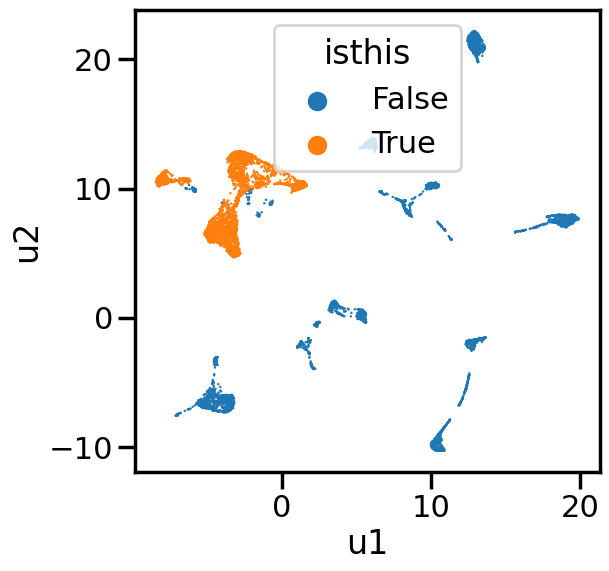

In [18]:
# df['isthis'] = df['cluster'].isin(['17'])
df['isthis'] = df['cluster'].isin(it_clusters)

fig, ax = plt.subplots(1,1, figsize=(6, 6))
sns.scatterplot(data=df, x='u1', y='u2', hue='isthis', s=3, edgecolor='none')

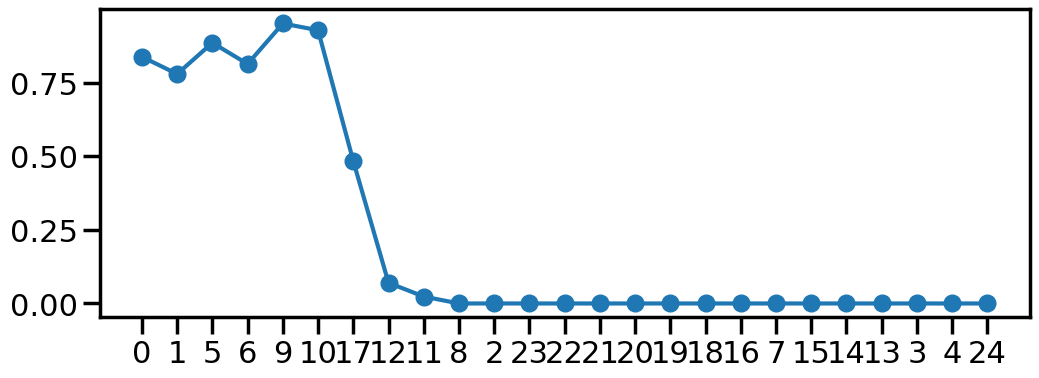

In [19]:
plt.figure(figsize=(12,4))
plt.plot(freqs[True], '-o')

# organize output

In [20]:
adata_query_it = adata_query[df['isthis']]

In [21]:
adata_query_it.write(f_anndata_out)